# Generating Figure Full WD J0212-552 spectrum

This is basically straight from my code for the Science paper, but adapted for ApJ. And probably using a narrower line

This is the same message at the beginning of all jupyter notebooks in this directory. 

If you don't have the below packages, you obviously need to install them for this to work. If it doesn't work still it's extremely likely you have an outdated version of one of the packages. Alternatively, some of the histogram functions actually rely on not being the most recent version because they changed from "normed" to something else from my recollection. Or perhaps it was the other way. I am aware this was poor decision-making, but it works (if you use the right version). ¯\\_(ツ)_/¯

Also pretty much all of these commands are copied and pasted from another Jupyter notebook I made but contained tons of tries at doing this stuff (and unrelated efforts) so that's why a lot of the variables seem unnecessary to use.

In [1]:
from __future__ import print_function


import matplotlib
#matplotlib.use('pdf')


import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp
import time
start = time.time()

sys.path.append('../')

import spec_plot_tools as spt
import cal_params as cp
import plot_spec as ps
import fix_strings as fs

print(os.getcwd())

all_avg
[]
/Users/BenKaiser/Desktop/radial_velocity_calculations/Kdwarf_impostor_plot_code


In [2]:
#target_dir= '/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/'
target_dir='/Users/BenKaiser/Desktop/Kdwarf_impostor_paper'
target_spec_file='ravg_fwctb.WDJ0212m5522_20231216_400m1.fits'
target_spec_file2='ravg_fwctb.WDJ0212m5522_20240111_400m2.fits'
#model_spec_file='J1644_fit_flambda.dms'
#target_spec_file= glob(target_dir+target_spec_file)
#model_spec_file= glob(target_dir+model_spec_file)
print(target_spec_file)
#print(model_spec_file)

ravg_fwctb.WDJ0212m5522_20231216_400m1.fits


In [3]:
#figure_output_dir='/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/First_Revision/figures'
#figure_output_dir='/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/Science_versions/Third_Revision/figures'
figure_output_dir='/Users/BenKaiser/Desktop/Kdwarf_impostor_paper/figures/'

In [4]:
#figure_output_dir='/Users/BenKaiser/Desktop/GaiaJ1644m0449_paper/ApJ_reformat/figures'

I guess I have to just change the working directory instead of using a long file path for whatever reason...

In [5]:
os.chdir(target_dir)

In [6]:
target_spec, header, target_noise= spt.retrieve_spec(target_spec_file)
target_spec2,header2, target_noise2=spt.retrieve_spec(target_spec_file2)

In [7]:
print(target_noise.shape)

(2, 1691)


model_spec= spt.retrieve_model_spec(model_spec_file)
model_spec[1]=model_spec[1]*1e16

og_model=np.copy(model_spec)

### *New addition 2021-06-04 for other stitching as a test (really should make a stitching script separate from this notebook... but I'm lazy...)

target_spec_file='ravg_fwctb.WD2356m209_400m1.fits'
target_spec_file2='ravg_fwctb.WD2356m209_20190601_ted_tellcorr_400m2.fits'
target_spec, header, target_noise= spt.retrieve_spec(target_spec_file)
target_spec2,header2, target_noise2=spt.retrieve_spec(target_spec_file2)

In [8]:
sm_target_spec=ps.convolve_spectrum(target_spec, header,kernel_type='box',pix_width=3)
sm_target_spec2=ps.convolve_spectrum(target_spec2, header2,kernel_type='box',pix_width=3)
trim_spot=6800



I rescale the flux in the 400M2 spectrum to match the 400M1 at this point. I suppose I could have it go the other way based on which one seems to be the better flux calibration. I don't remember why this flux calibration is so comparatively bad though.

In [9]:
#nsm_target_spec=ps.norm_spectrum(sm_target_spec,norm_range=[trim_spot-20,trim_spot+20])
#nsm_target_spec2=ps.norm_spectrum(sm_target_spec2,norm_range=[trim_spot-20,trim_spot+20])
mean_1=np.nanmean(sm_target_spec[1][np.where((sm_target_spec[0]>trim_spot-20)& (sm_target_spec[0]<trim_spot+20))])
mean_2=np.nanmean(sm_target_spec2[1][np.where((sm_target_spec2[0]>trim_spot-20)& (sm_target_spec2[0]<trim_spot+20))])

scale_factor=mean_1/mean_2

sm_target_spec2[1]=sm_target_spec2[1]*scale_factor

print(mean_1)

0.9241570556381113


In [10]:
tsm_target_spec=spt.clean_spectrum(sm_target_spec,np.min(target_spec[0]), trim_spot,[])
tsm_target_spec2=spt.clean_spectrum(sm_target_spec2,trim_spot, np.max(target_spec2[0]),[])
#tsm_target_spec=spt.clean_spectrum(target_spec,np.min(target_spec[0]), trim_spot,[])
#tsm_target_spec2=spt.clean_spectrum(target_spec2,trim_spot, np.max(target_spec2[0]),[])
#tsm_target_spec=spt.clean_spectrum(nsm_target_spec,np.min(target_spec[0]), trim_spot,[])
#tsm_target_spec2=spt.clean_spectrum(nsm_target_spec2,trim_spot, np.max(target_spec2[0]),[])


#tmodel_spec=spt.clean_spectrum(og_model, np.nanmin(target_spec[0]), np.nanmax(target_spec2[0]),[])

/Users/BenKaiser/Desktop/Kdwarf_impostor_paper
/Users/BenKaiser/Desktop/Kdwarf_impostor_paper/figures
1768542891.061503


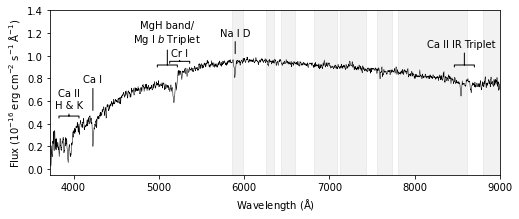

In [11]:
#plt.rc('font',size=10)
#fig= plt.figure(figsize=(15,10)) #from v1 description image size
#spt.initiate_science_plot()
#fig=plt.figure(figsize=(7.25,7.25*2./3),constrained_layout=True)
#spt.start_ApJ_fig(width_cols=2,constrained_layout=True, width_height=[7.25,7.25*2./3])
spt.start_ApJ_fig(width_cols=2,constrained_layout=True, width_height=[7.25,3])
label_pos=1.27
label_pos2= 0.8
label_off=130


plt.plot(tsm_target_spec[0],tsm_target_spec[1], label=fs.fix_display_string("WD J0212–5522"), color='k')
plt.plot(tsm_target_spec2[0],tsm_target_spec2[1], color='k')
#plt.plot(tmodel_spec[0],tmodel_spec[1], label='Best Fit Model', color='r',alpha=0.7)


plt.xlim(np.nanmin(target_spec[0]), 9000)
plt.ylim(-0.05, 1.4)

k_spot=np.mean([7664.899016,7698.96445153])


#plt.annotate('Li I',xy=(6707.9080032878719, 0.21),xytext=(6707.9080032878719-55, label_pos), arrowprops=dict(arrowstyle='-'))
#plt.annotate('Ca II\nH & K',xy=((3924+3968.4672118153667)/2, 0.45),xytext=(0, 50), arrowprops=dict(arrowstyle='-['),textcoords='offset points', ha='center')
#plt.annotate('Ca I',xy=(4226.7295809531952, 0.5),xytext=(0, 70), arrowprops=dict(arrowstyle='-'),textcoords='offset points', ha='center')
#plt.annotate('MgH band &\nNa-He QM line',xy=(5190, 0.16),xytext=(5190-260, label_pos-0.05), arrowprops=dict(arrowstyle='-['))
#plt.annotate('MgH band/\nMg I $b$ Triplet',xy=(5100, 0.9),xytext=(0, 70), arrowprops=dict(arrowstyle='-['),textcoords='offset points', ha='center')
#plt.annotate('K I',xy=(k_spot, 0.25),xytext=(k_spot-60, label_pos), arrowprops=dict(arrowstyle='-['))
#plt.annotate(r'Cr I',xy=(5245, 0.95),xytext=(0, 20), arrowprops=dict(arrowstyle='-['),textcoords='offset points', ha='center')
#plt.annotate('Na I D',xy=(5895.9241497669427, 1.0),xytext=(0, 60), arrowprops=dict(arrowstyle='-'),textcoords='offset points', ha='center')

#plt.annotate(r'Ca II IR Triplet  ',xy=(8584, 0.9),xytext=(0, 60), arrowprops=dict(arrowstyle='-['),textcoords='offset points', ha='center')


#plt.annotate('Li I',xy=(6707.9080032878719, 0.21),xytext=(6707.9080032878719-55, label_pos), arrowprops=dict(arrowstyle='-'))
plt.annotate('Ca II\nH & K',xy=((3924+3968.4672118153667)/2, 0.45),xytext=(0, 10), arrowprops=dict(arrowstyle='-['),textcoords='offset points', ha='center')
plt.annotate('Ca I',xy=(4226.7295809531952, 0.5),xytext=(0, 30), arrowprops=dict(arrowstyle='-'),textcoords='offset points', ha='center')
#plt.annotate('MgH band &\nNa-He QM line',xy=(5190, 0.16),xytext=(5190-260, label_pos-0.05), arrowprops=dict(arrowstyle='-['))
plt.annotate('MgH band/\nMg I $b$ Triplet',xy=(5100, 0.9),xytext=(0, 25), arrowprops=dict(arrowstyle='-['),textcoords='offset points', ha='center')
#plt.annotate('K I',xy=(k_spot, 0.25),xytext=(k_spot-60, label_pos), arrowprops=dict(arrowstyle='-['))
plt.annotate(r'Cr I',xy=(5245, 0.95),xytext=(0, 5), arrowprops=dict(arrowstyle='-['),textcoords='offset points', ha='center')
plt.annotate('Na I D',xy=(5895.9241497669427, 1.0),xytext=(0, 20), arrowprops=dict(arrowstyle='-'),textcoords='offset points', ha='center')

plt.annotate(r'Ca II IR Triplet  ',xy=(8584, 0.9),xytext=(0, 20), arrowprops=dict(arrowstyle='-['),textcoords='offset points', ha='center')





#plt.xlim(6000,8000)
#plt.ylabel(r'$f_{\lambda} (10^{-16} erg/ cm^{2}/s/ \AA)$')
#plt.ylabel(r'$f_{\lambda}$ ($10^{-16}$ erg/cm$^{2}$/s/$\AA$)')
#plt.ylabel(r'Flux ($10^{-16}$ erg/cm$^{2}$/s/$\mathrm{\AA}$)')

#plt.ylabel(r'$f_{\lambda} (10^{-16}$ erg cm$^{-2}$ s $^{-1}$ $\AA^{-1})$') #inverse power units instead of divisions
plt.ylabel(r'Flux (10$^{-16}$ erg cm$^{-2}$ s$^{-1}$ $\mathrm{\AA}^{-1}$)') #inverse power units instead of divisions




#plt.xlabel(r'$\lambda(\AA)$')
#plt.xlabel(r'Wavelength $(\AA)$')
plt.xlabel(r'Wavelength $(\mathrm{\AA})$')



#spt.show_plot(line_id='alkali', label_pos=0.25, convert_to_air=True)
spt.show_plot(line_id='',show_legend=False,actually_show=False)


print(os.getcwd())
os.chdir(figure_output_dir)
print(os.getcwd())
start = time.time()
print(start)
time_string=str(start).split('.')[0]

#plt.legend(loc='lower right')
plt.savefig('WDJ0212fullspec_'+time_string+'.pdf')#plt.grid(True)

plt.show()

os.chdir(target_dir)
trim_spot=6800
hdu1= fits.open(target_spec_file)
hdu2=fits.open(target_spec_file2)
waves1=hdu1[0].data
waves2=hdu2[0].data

#output_fits='stitched_J1644_spectrum.fits'
output_fits='stitched_J2356_spectrum.fits'

list_for_hdu=[]
for index in range(0,5):
    array1=np.copy(hdu1[index].data)
    array2=np.copy(hdu2[index].data)
    spec1=np.vstack([waves1,array1])
    spec2=np.vstack([waves2,array2])
    print(spec1.shape)
    tsm_spec1=spt.clean_spectrum(spec1,np.min(spec1[0]), trim_spot,[])
    tsm_spec2=spt.clean_spectrum(spec2,trim_spot, np.max(spec2[0]),[])
    stitched_spec=np.hstack([tsm_spec1,tsm_spec2])
    print(stitched_spec.shape)
    if index==0:
        out_hdu=fits.PrimaryHDU(stitched_spec[1], header=header)
        list_for_hdu.append(out_hdu)
    else:
        new_hdu=fits.ImageHDU(stitched_spec[1])
        list_for_hdu.append(new_hdu)
        
print(list_for_hdu)
hdulist=fits.HDUList(list_for_hdu)
os.chdir(figure_output_dir)
hdulist.writeto(output_fits)